# Kickstarter Funding Prediction — 10 Models + Bagging, Stacking, and Blending

This notebook compares 10 individual regression models and three ensemble methods:

**Individual models:** Random Forest, Extra Trees, XGBoost, KNN, Ridge, Linear Regression, SVR, Decision Tree, AdaBoost, CatBoost.

**Ensembles:** Bagging, Stacking, and Blending.

The target is `log_target = log1p(target_usd)`. Predictions are converted back to USD using `expm1()`.

All ensemble predictions are evaluated with the same metrics as the individual models.


## Cell 1 — Imports


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    StackingRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)

try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError(
        "xgboost is not installed. Run: pip install xgboost"
    )

try:
    from catboost import CatBoostRegressor
except ImportError:
    raise ImportError(
        "catboost is not installed. Run: pip install catboost"
    )

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)


## Cell 2 — Load final train and test datasets


In [13]:
TRAIN_FILE = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset\ML_train.csv"
TEST_FILE = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset\ML_test.csv"

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())


Train shape: (16000, 81)
Test shape: (4000, 81)


,id,goal_usd,log_goal_usd,duration_days,prelaunch_days,name_char_length,name_word_count,blurb_char_length,blurb_word_count,launch_year,launch_month,launch_day,launch_weekday,launch_hour,has_video,prelaunch_activated,category_name_freq,location_country_freq,location_state_freq,country_AU,country_BE,country_CA,country_CH,country_DE,country_DK,country_ES,country_FR,country_GB,country_GR,country_HK,country_IE,country_IT,country_JP,country_LU,country_MX,country_NL,country_NO,country_NZ,country_PL,country_SE,country_SG,country_SI,country_US,currency_CAD,currency_CHF,currency_DKK,currency_EUR,currency_GBP,currency_HKD,currency_JPY,currency_MXN,currency_NOK,currency_NZD,currency_PLN,currency_SEK,currency_SGD,currency_USD,category_parent_Comics,category_parent_Crafts,category_parent_Dance,category_parent_Design,category_parent_Fashion,category_parent_Film & Video,category_parent_Food,category_parent_Games,category_parent_Journalism,category_parent_Music,category_parent_Photography,category_parent_Publishing,category_parent_Technology,category_parent_Theater,location_type_County,location_type_Island,location_type_LocalAdmin,location_type_Miscellaneous,location_type_Suburb,location_type_Town,location_type_Unknown,location_type_Zip,target_usd,log_target
0,160053502,1490.1241,7.307286,30.000000,13.537003,30.0,5.0,25.0,5.0,2020.0,6.0,8.0,0.0,15.0,1.0,1.0,0.006625,0.045937,0.009750,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2694.360622,7.899287
1,1797462698,5000.0000,8.517393,35.041668,18.665070,8.0,2.0,108.0,18.0,2017.0,10.0,17.0,1.0,13.0,1.0,0.0,0.009813,0.622313,0.037000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,122.000000,4.812184
2,1582340481,10000.0000,9.210441,30.000000,10.058495,53.0,7.0,108.0,13.0,2025.0,1.0,3.0,4.0,2.0,1.0,0.0,0.006125,0.622313,0.106500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000
3,498571554,15475.7350,9.647093,29.958334,7.044641,39.0,7.0,110.0,18.0,2022.0,3.0,11.0,4.0,12.0,0.0,1.0,0.015813,0.003125,0.001500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26102.038065,10.169807
4,1914908476,1400.0000,7.244942,60.000000,13.044236,29.0,5.0,125.0,24.0,2025.0,3.0,23.0,6.0,21.0,1.0,0.0,0.011187,0.622313,0.033125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1478.000000,7.299121


## Cell 3 — Define X and y


In [14]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"

DROP_FROM_X = [
    "id",
    "target_usd",
    "log_target",
    "goal_usd"
]

X_train = train_df.drop(
    columns=DROP_FROM_X,
    errors="ignore"
)

X_test = test_df.drop(
    columns=DROP_FROM_X,
    errors="ignore"
)

y_train = train_df[TARGET_LOG].copy()
y_test = test_df[TARGET_LOG].copy()

actual_usd = test_df[TARGET_RAW].to_numpy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Number of features:", X_train.shape[1])


X_train: (16000, 77)
X_test: (4000, 77)
y_train: (16000,)
y_test: (4000,)
Number of features: 77


## Cell 4 — Verify feature setup


In [15]:
assert "id" not in X_train.columns
assert "target_usd" not in X_train.columns
assert "log_target" not in X_train.columns
assert "goal_usd" not in X_train.columns
assert "log_goal_usd" in X_train.columns

assert list(X_train.columns) == list(X_test.columns)

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("Feature setup is valid.")
print("No target leakage detected.")
print("No missing values in X.")


Feature setup is valid.
No target leakage detected.
No missing values in X.


## Cell 4b — Fit StandardScaler (for linear / distance-based models)

Tree-based models (Random Forest, Extra Trees, XGBoost, Decision Tree, AdaBoost, CatBoost) do **not** need scaling.
Linear and distance-based models (KNN, Ridge, Linear Regression, SVR) **do** need scaling.
We fit the scaler on `X_train` only.


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaler fitted on X_train.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled  shape:", X_test_scaled.shape)


Scaler fitted on X_train.
X_train_scaled shape: (16000, 77)
X_test_scaled  shape: (4000, 77)


## Cell 6 — Evaluation helper

This function calculates:

- MAE on log scale
- RMSE on log scale
- R² on log scale
- MAE in USD
- RMSE in USD
- MSE in USD  *(new)*
- R² in USD
- RMSLE
- MSE (log scale)  *(new)*

The model predicts `log_target`, then predictions are transformed back into USD.


In [17]:
def evaluate_model(
    model_name,
    y_true_log,
    pred_log,
    actual_usd
):

    pred_usd = np.expm1(
        pred_log
    )

    pred_usd = np.clip(
        pred_usd,
        a_min=0,
        a_max=None
    )

    mae_log = mean_absolute_error(
        y_true_log,
        pred_log
    )

    mse_log = mean_squared_error(
        y_true_log,
        pred_log
    )

    rmse_log = np.sqrt(mse_log)

    r2_log = r2_score(
        y_true_log,
        pred_log
    )

    mae_usd = mean_absolute_error(
        actual_usd,
        pred_usd
    )

    mse_usd = mean_squared_error(
        actual_usd,
        pred_usd
    )

    rmse_usd = np.sqrt(mse_usd)

    r2_usd = r2_score(
        actual_usd,
        pred_usd
    )

    rmsle = np.sqrt(
        mean_squared_log_error(
            actual_usd,
            pred_usd
        )
    )

    metrics = {
        "Model":        model_name,
        "MAE_log":      mae_log,
        "MSE_log":      mse_log,
        "RMSE_log":     rmse_log,
        "R2_log":       r2_log,
        "MAE_USD":      mae_usd,
        "MSE_USD":      mse_usd,
        "RMSE_USD":     rmse_usd,
        "R2_USD":       r2_usd,
        "RMSLE":        rmsle
    }

    return metrics, pred_usd


# Random Forest


## Cell 7 — Create Random Forest model


In [18]:
random_forest = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

print(random_forest)


RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=4, n_estimators=500, n_jobs=-1,
                      random_state=42)


## Cell 8 — Train Random Forest


In [19]:
start_time = time.time()

random_forest.fit(
    X_train,
    y_train
)

rf_training_time = (
    time.time()
    - start_time
)

print(
    f"Random Forest training completed in "
    f"{rf_training_time:.2f} seconds"
)


Random Forest training completed in 3.04 seconds


## Cell 9 — Predict and evaluate Random Forest


In [20]:
rf_pred_log = random_forest.predict(
    X_test
)

rf_metrics, rf_pred_usd = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred_log,
    actual_usd
)

rf_metrics["Training_Time_Seconds"] = rf_training_time

display(
    pd.DataFrame([rf_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Random Forest,1.785039,5.661209,2.379329,0.397407,16900.088685,1.169296e+10,108133.996923,0.009197,2.379329,3.035647


# Extra Trees


## Cell 10 — Create Extra Trees model


In [21]:
extra_trees = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

print(extra_trees)


ExtraTreesRegressor(max_features='sqrt', min_samples_leaf=2,
                    min_samples_split=4, n_estimators=500, n_jobs=-1,
                    random_state=42)


## Cell 11 — Train Extra Trees


In [22]:
start_time = time.time()

extra_trees.fit(
    X_train,
    y_train
)

et_training_time = (
    time.time()
    - start_time
)

print(
    f"Extra Trees training completed in "
    f"{et_training_time:.2f} seconds"
)


Extra Trees training completed in 3.86 seconds


## Cell 12 — Predict and evaluate Extra Trees


In [23]:
et_pred_log = extra_trees.predict(
    X_test
)

et_metrics, et_pred_usd = evaluate_model(
    "Extra Trees",
    y_test,
    et_pred_log,
    actual_usd
)

et_metrics["Training_Time_Seconds"] = et_training_time

display(
    pd.DataFrame([et_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Extra Trees,1.881252,6.161658,2.482269,0.344138,17211.141009,1.176452e+10,108464.371682,0.003133,2.482269,3.863901


# XGBoost


## Cell 13 — Create XGBoost model

These are reasonable starting hyperparameters, not final tuned values.


In [24]:
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1,
    random_state=42
)

print(xgb_model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)


## Cell 14 — Train XGBoost


In [25]:
start_time = time.time()

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_test, y_test)
    ],
    verbose=False
)

xgb_training_time = (
    time.time()
    - start_time
)

print(
    f"XGBoost training completed in "
    f"{xgb_training_time:.2f} seconds"
)


XGBoost training completed in 5.34 seconds


## Cell 15 — Predict and evaluate XGBoost


In [26]:
xgb_pred_log = xgb_model.predict(
    X_test
)

xgb_metrics, xgb_pred_usd = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred_log,
    actual_usd
)

xgb_metrics["Training_Time_Seconds"] = xgb_training_time

display(
    pd.DataFrame([xgb_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,XGBoost,1.646085,5.009731,2.238243,0.466752,16028.48593,1.099029e+10,104834.606331,0.068737,2.238243,5.33818


# KNN Regressor


## Cell 16 — Create KNN model

KNN uses `X_train_scaled` / `X_test_scaled`.


In [27]:
knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    n_jobs=-1
)

print(knn_model)


KNeighborsRegressor(n_jobs=-1, n_neighbors=10, weights='distance')


## Cell 17 — Train KNN


In [28]:
start_time = time.time()

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_training_time = (
    time.time()
    - start_time
)

print(
    f"KNN training completed in "
    f"{knn_training_time:.2f} seconds"
)


KNN training completed in 0.01 seconds


## Cell 18 — Predict and evaluate KNN


In [29]:
knn_pred_log = knn_model.predict(
    X_test_scaled
)

knn_metrics, knn_pred_usd = evaluate_model(
    "KNN",
    y_test,
    knn_pred_log,
    actual_usd
)

knn_metrics["Training_Time_Seconds"] = knn_training_time

display(
    pd.DataFrame([knn_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,KNN,1.982279,7.260325,2.694499,0.227193,17259.30992,1.146411e+10,107070.605188,0.028588,2.694499,0.009029


# Ridge Regression


## Cell 19 — Create Ridge model


In [30]:
ridge_model = Ridge(
    alpha=1.0
)

print(ridge_model)


Ridge()


## Cell 20 — Train Ridge


In [31]:
start_time = time.time()

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_training_time = (
    time.time()
    - start_time
)

print(
    f"Ridge training completed in "
    f"{ridge_training_time:.2f} seconds"
)


Ridge training completed in 0.12 seconds


## Cell 21 — Predict and evaluate Ridge


In [32]:
ridge_pred_log = ridge_model.predict(
    X_test_scaled
)

ridge_metrics, ridge_pred_usd = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred_log,
    actual_usd
)

ridge_metrics["Training_Time_Seconds"] = ridge_training_time

display(
    pd.DataFrame([ridge_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Ridge Regression,2.040626,6.966751,2.63946,0.258441,17521.775331,1.169904e+10,108162.081021,0.008682,2.63946,0.122123


# Linear Regression


## Cell 22 — Create Linear Regression model


In [33]:
lr_model = LinearRegression(
    n_jobs=-1
)

print(lr_model)


LinearRegression(n_jobs=-1)


## Cell 23 — Train Linear Regression


In [34]:
start_time = time.time()

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_training_time = (
    time.time()
    - start_time
)

print(
    f"Linear Regression training completed in "
    f"{lr_training_time:.2f} seconds"
)


Linear Regression training completed in 0.10 seconds


## Cell 24 — Predict and evaluate Linear Regression


In [35]:
lr_pred_log = lr_model.predict(
    X_test_scaled
)

lr_metrics, lr_pred_usd = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred_log,
    actual_usd
)

lr_metrics["Training_Time_Seconds"] = lr_training_time

display(
    pd.DataFrame([lr_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Linear Regression,2.040627,6.966781,2.639466,0.258438,17521.738351,1.169888e+10,108161.378497,0.008695,2.639466,0.101333


# SVR (Support Vector Regressor)


## Cell 25 — Create SVR model

SVR can be slow on large datasets. Using RBF kernel as baseline.


In [36]:
svr_model = SVR(
    kernel="rbf",
    C=1.0,
    epsilon=0.1
)

print(svr_model)


SVR()


## Cell 26 — Train SVR


In [37]:
start_time = time.time()

svr_model.fit(
    X_train_scaled,
    y_train
)

svr_training_time = (
    time.time()
    - start_time
)

print(
    f"SVR training completed in "
    f"{svr_training_time:.2f} seconds"
)


SVR training completed in 18.04 seconds


## Cell 27 — Predict and evaluate SVR


In [38]:
svr_pred_log = svr_model.predict(
    X_test_scaled
)

svr_metrics, svr_pred_usd = evaluate_model(
    "SVR",
    y_test,
    svr_pred_log,
    actual_usd
)

svr_metrics["Training_Time_Seconds"] = svr_training_time

display(
    pd.DataFrame([svr_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,SVR,1.802737,6.875649,2.622146,0.268139,16423.625554,1.132263e+10,106407.868452,0.040576,2.622146,18.040984


# Decision Tree Regressor


## Cell 28 — Create Decision Tree model


In [39]:
dt_model = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

print(dt_model)


DecisionTreeRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=4,
                      random_state=42)


## Cell 29 — Train Decision Tree


In [40]:
start_time = time.time()

dt_model.fit(
    X_train,
    y_train
)

dt_training_time = (
    time.time()
    - start_time
)

print(
    f"Decision Tree training completed in "
    f"{dt_training_time:.2f} seconds"
)


Decision Tree training completed in 0.19 seconds


## Cell 30 — Predict and evaluate Decision Tree


In [41]:
dt_pred_log = dt_model.predict(
    X_test
)

dt_metrics, dt_pred_usd = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred_log,
    actual_usd
)

dt_metrics["Training_Time_Seconds"] = dt_training_time

display(
    pd.DataFrame([dt_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Decision Tree,2.000275,8.131532,2.851584,0.134459,17330.575316,1.087614e+10,104288.724471,0.07841,2.851584,0.189002


# AdaBoost Regressor


## Cell 31 — Create AdaBoost model


In [42]:
adaboost_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.1,
    loss="linear",
    random_state=42
)

print(adaboost_model)


AdaBoostRegressor(learning_rate=0.1, n_estimators=200, random_state=42)


## Cell 32 — Train AdaBoost


In [43]:
start_time = time.time()

adaboost_model.fit(
    X_train,
    y_train
)

ada_training_time = (
    time.time()
    - start_time
)

print(
    f"AdaBoost training completed in "
    f"{ada_training_time:.2f} seconds"
)


AdaBoost training completed in 13.22 seconds


## Cell 33 — Predict and evaluate AdaBoost


In [44]:
ada_pred_log = adaboost_model.predict(
    X_test
)

ada_metrics, ada_pred_usd = evaluate_model(
    "AdaBoost",
    y_test,
    ada_pred_log,
    actual_usd
)

ada_metrics["Training_Time_Seconds"] = ada_training_time

display(
    pd.DataFrame([ada_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,AdaBoost,2.310561,7.535397,2.745068,0.197913,18157.750108,1.206369e+10,109834.819278,-0.022217,2.745068,13.220879


# CatBoost Regressor


## Cell 34 — Create CatBoost model


In [45]:
catboost_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=3.0,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False
)

print(catboost_model)


CatBoostRegressor(depth=7, eval_metric='RMSE', iterations=800, l2_leaf_reg=3.0, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)


## Cell 35 — Train CatBoost


In [46]:
start_time = time.time()

catboost_model.fit(
    X_train,
    y_train,
    eval_set=(
        X_test,
        y_test
    ),
    use_best_model=False
)

cat_training_time = (
    time.time()
    - start_time
)

print(
    f"CatBoost training completed in "
    f"{cat_training_time:.2f} seconds"
)


CatBoost training completed in 4.61 seconds


## Cell 36 — Predict and evaluate CatBoost


In [47]:
cat_pred_log = catboost_model.predict(
    X_test
)

cat_metrics, cat_pred_usd = evaluate_model(
    "CatBoost",
    y_test,
    cat_pred_log,
    actual_usd
)

cat_metrics["Training_Time_Seconds"] = cat_training_time

display(
    pd.DataFrame([cat_metrics])
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,CatBoost,1.674253,5.126251,2.264123,0.454349,16270.405727,1.134479e+10,106511.925626,0.038699,2.264123,4.608507


# Ensemble Learning — Bagging

Bagging uses bootstrap samples to train multiple decision trees in parallel and averages their regression predictions. For regression, `oob_score_` is an OOB R² score; OOB error is reported as `1 - OOB R²`.

In [48]:
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    ),
    n_estimators=100,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

print(bagging_model)


BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=12,
                                                 min_samples_leaf=2,
                                                 min_samples_split=4,
                                                 random_state=42),
                 max_samples=0.8, n_estimators=100, n_jobs=-1, oob_score=True,
                 random_state=42)


In [49]:
start_time = time.time()

bagging_model.fit(
    X_train,
    y_train
)

bagging_training_time = time.time() - start_time

print(f"Bagging training completed in {bagging_training_time:.2f} seconds")
print(f"OOB R²: {bagging_model.oob_score_:.4f}")
print(f"OOB error (1 - OOB R²): {1.0 - bagging_model.oob_score_:.4f}")


Bagging training completed in 11.01 seconds
OOB R²: 0.3933
OOB error (1 - OOB R²): 0.6067


In [50]:
bagging_pred_log = bagging_model.predict(X_test)

bagging_metrics, bagging_pred_usd = evaluate_model(
    "Bagging",
    y_test,
    bagging_pred_log,
    actual_usd
)

bagging_metrics["Training_Time_Seconds"] = bagging_training_time

display(pd.DataFrame([bagging_metrics]))


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Bagging,1.761423,5.777244,2.40359,0.385056,16610.141094,1.158942e+10,107654.159676,0.01797,2.40359,11.006536


# Ensemble Learning — Stacking

Stacking combines diverse base regressors and trains a Ridge meta-model on out-of-fold predictions. A pipeline is used for SVR so scaling is learned only inside each training fold.

In [51]:
# ============================================================
# NEW STACKING MODEL
# Base Models:
#   1. CatBoost
#   2. Random Forest
#   3. Extra Trees
#
# Meta Model:
#   XGBoost
#
# Validation:
#   5-Fold Cross-Validation / OOF predictions
# ============================================================

stacking_estimators = [

    (
        "cat",
        CatBoostRegressor(
            iterations=800,
            learning_rate=0.03,
            depth=7,
            l2_leaf_reg=3.0,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=42,
            verbose=False
        )
    ),

    (
        "rf",
        RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
    ),

    (
        "extra",
        ExtraTreesRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
    )
]


# ------------------------------------------------------------
# XGBoost = META MODEL
# ------------------------------------------------------------

stacking_meta_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1,
    random_state=42
)


# ------------------------------------------------------------
# STACKING REGRESSOR
# ------------------------------------------------------------

stacking_model = StackingRegressor(
    estimators=stacking_estimators,

    # XGBoost is now the META MODEL
    final_estimator=stacking_meta_model,

    # 5-fold OOF predictions
    cv=5,

    # Parallel training
    n_jobs=-1
)


print("=" * 70)
print("NEW STACKING MODEL")
print("=" * 70)

print("Base Models:")
print("  1. CatBoost")
print("  2. Random Forest")
print("  3. Extra Trees")

print("\nMeta Model:")
print("  XGBoost")

print("\nValidation:")
print("  5-Fold Cross-Validation")

print("=" * 70)
print(stacking_model)


# ------------------------------------------------------------
# TRAIN STACKING
# ------------------------------------------------------------

start_time = time.time()

stacking_model.fit(
    X_train,
    y_train
)

stacking_training_time = time.time() - start_time

print(
    f"\nStacking training completed in "
    f"{stacking_training_time:.2f} seconds"
)


# ------------------------------------------------------------
# TEST PREDICTION
# ------------------------------------------------------------

stacking_pred_log = stacking_model.predict(X_test)


# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

stacking_metrics, stacking_pred_usd = evaluate_model(
    "Stacking",
    y_test,
    stacking_pred_log,
    actual_usd
)

stacking_metrics["Training_Time_Seconds"] = stacking_training_time


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

display(
    pd.DataFrame([stacking_metrics])
)

NEW STACKING MODEL
Base Models:
  1. CatBoost
  2. Random Forest
  3. Extra Trees

Meta Model:
  XGBoost

Validation:
  5-Fold Cross-Validation
StackingRegressor(cv=5,
                  estimators=[('cat',
                               CatBoostRegressor(depth=7, eval_metric='RMSE', iterations=800, l2_leaf_reg=3.0, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)),
                              ('rf',
                               RandomForestRegressor(max_features='sqrt',
                                                     min_samples_leaf=2,
                                                     min_samples_split=4,
                                                     n_estimators=500,
                                                     n_jobs=-1,
                                                     random_state=42)),
                              ('extra',
                               ExtraTreesRegressor(...
                                               f

,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Stacking,1.733225,5.519882,2.349443,0.41245,16481.606102,1.114187e+10,105555.078142,0.055893,2.349443,66.543658


In [52]:
# stacking_estimators = [
#     (
#         "rf",
#         RandomForestRegressor(
#             n_estimators=500,
#             max_depth=None,
#             min_samples_split=4,
#             min_samples_leaf=2,
#             max_features="sqrt",
#             n_jobs=-1,
#             random_state=42
#         )
#     ),
#     (
#         "extra",
#         ExtraTreesRegressor(
#             n_estimators=500,
#             max_depth=None,
#             min_samples_split=4,
#             min_samples_leaf=2,
#             max_features="sqrt",
#             n_jobs=-1,
#             random_state=42
#         )
#     ),
#     (
#         "xgb",
#         XGBRegressor(
#             n_estimators=800,
#             learning_rate=0.03,
#             max_depth=7,
#             min_child_weight=3,
#             subsample=0.85,
#             colsample_bytree=0.85,
#             reg_alpha=0.05,
#             reg_lambda=1.0,
#             objective="reg:squarederror",
#             eval_metric="rmse",
#             n_jobs=-1,
#             random_state=42
#         )
#     ),
#     (
#         "cat",
#         CatBoostRegressor(
#             iterations=800,
#             learning_rate=0.03,
#             depth=7,
#             l2_leaf_reg=3.0,
#             loss_function="RMSE",
#             eval_metric="RMSE",
#             random_seed=42,
#             verbose=False
#         )
#     ),
#     (
#         "svr",
#         make_pipeline(
#             StandardScaler(),
#             SVR(kernel="rbf", C=1.0, epsilon=0.1)
#         )
#     )
# ]

# stacking_model = StackingRegressor(
#     estimators=stacking_estimators,
#     final_estimator=Ridge(alpha=1.0),
#     cv=5,
#     n_jobs=-1
# )

# print(stacking_model)


In [53]:
# start_time = time.time()

# stacking_model.fit(
#     X_train,
#     y_train
# )

# stacking_training_time = time.time() - start_time

# print(f"Stacking training completed in {stacking_training_time:.2f} seconds")


In [54]:
# stacking_pred_log = stacking_model.predict(X_test)

# stacking_metrics, stacking_pred_usd = evaluate_model(
#     "Stacking",
#     y_test,
#     stacking_pred_log,
#     actual_usd
# )

# stacking_metrics["Training_Time_Seconds"] = stacking_training_time

# display(pd.DataFrame([stacking_metrics]))


# Ensemble Learning — Blending

Blending combines predictions from independently trained models using fixed weights. The weights below sum to 1.0 and are deliberately fixed rather than tuned on the test set, keeping the test set reserved for final evaluation.

In [55]:
blend_weights = {
    "Random Forest": 0.25,
    "XGBoost": 0.35,
    "CatBoost": 0.40
}

assert np.isclose(sum(blend_weights.values()), 1.0)

print("Blending weights:", blend_weights)


Blending weights: {'Random Forest': 0.25, 'XGBoost': 0.35, 'CatBoost': 0.4}


In [56]:
start_time = time.time()

blend_pred_log = (
    blend_weights["Random Forest"] * rf_pred_log
    + blend_weights["XGBoost"] * xgb_pred_log
    + blend_weights["CatBoost"] * cat_pred_log
)

blending_prediction_time = time.time() - start_time

blend_metrics, blend_pred_usd = evaluate_model(
    "Blending",
    y_test,
    blend_pred_log,
    actual_usd
)

blend_metrics["Training_Time_Seconds"] = blending_prediction_time

display(pd.DataFrame([blend_metrics]))


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Blending,1.666266,5.082775,2.254501,0.458977,16283.199212,1.138115e+10,106682.46331,0.035618,2.254501,0.001005


# Ensemble Comparison

The following cell adds Bagging, Stacking, and Blending to the original 10-model comparison.

# Model Comparison


## Final Comparison — 10 Individual Models + 3 Ensembles


In [57]:
comparison_df = pd.DataFrame([
    rf_metrics,
    et_metrics,
    xgb_metrics,
    knn_metrics,
    ridge_metrics,
    lr_metrics,
    svr_metrics,
    dt_metrics,
    ada_metrics,
    cat_metrics,
    bagging_metrics,
    stacking_metrics,
    blend_metrics
])

comparison_df = comparison_df[
    [
        "Model",
        "MAE_log",
        "MSE_log",
        "RMSE_log",
        "R2_log",
        "MAE_USD",
        "MSE_USD",
        "RMSE_USD",
        "R2_USD",
        "RMSLE",
        "Training_Time_Seconds"
    ]
]

display(
    comparison_df
    .sort_values("RMSLE")
    .reset_index(drop=True)
)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,XGBoost,1.646085,5.009731,2.238243,0.466752,16028.485930,1.099029e+10,104834.606331,0.068737,2.238243,5.338180
1,Blending,1.666266,5.082775,2.254501,0.458977,16283.199212,1.138115e+10,106682.463310,0.035618,2.254501,0.001005
2,CatBoost,1.674253,5.126251,2.264123,0.454349,16270.405727,1.134479e+10,106511.925626,0.038699,2.264123,4.608507
3,Stacking,1.733225,5.519882,2.349443,0.412450,16481.606102,1.114187e+10,105555.078142,0.055893,2.349443,66.543658
4,Random Forest,1.785039,5.661209,2.379329,0.397407,16900.088685,1.169296e+10,108133.996923,0.009197,2.379329,3.035647
5,Bagging,1.761423,5.777244,2.403590,0.385056,16610.141094,1.158942e+10,107654.159676,0.017970,2.403590,11.006536
6,Extra Trees,1.881252,6.161658,2.482269,0.344138,17211.141009,1.176452e+10,108464.371682,0.003133,2.482269,3.863901
7,SVR,1.802737,6.875649,2.622146,0.268139,16423.625554,1.132263e+10,106407.868452,0.040576,2.622146,18.040984
8,Ridge Regression,2.040626,6.966751,2.639460,0.258441,17521.775331,1.169904e+10,108162.081021,0.008682,2.639460,0.122123
9,Linear Regression,2.040627,6.966781,2.639466,0.258438,17521.738351,1.169888e+10,108161.378497,0.008695,2.639466,0.101333


## Cell 37 — Nicely formatted comparison

Lower is better for MAE, MSE, RMSE, RMSLE.  Higher is better for R².


In [58]:
formatted_comparison = comparison_df.copy()

for col in ["MAE_log", "MSE_log", "RMSE_log", "R2_log"]:
    formatted_comparison[col] = (
        formatted_comparison[col]
        .map(lambda x: f"{x:.4f}")
    )

formatted_comparison["MAE_USD"] = (
    formatted_comparison["MAE_USD"]
    .map(lambda x: f"${x:,.2f}")
)

formatted_comparison["MSE_USD"] = (
    formatted_comparison["MSE_USD"]
    .map(lambda x: f"{x:,.0f}")
)

formatted_comparison["RMSE_USD"] = (
    formatted_comparison["RMSE_USD"]
    .map(lambda x: f"${x:,.2f}")
)

formatted_comparison["R2_USD"] = (
    formatted_comparison["R2_USD"]
    .map(lambda x: f"{x:.4f}")
)

formatted_comparison["RMSLE"] = (
    formatted_comparison["RMSLE"]
    .map(lambda x: f"{x:.4f}")
)

formatted_comparison["Training_Time_Seconds"] = (
    formatted_comparison["Training_Time_Seconds"]
    .map(lambda x: f"{x:.2f}s")
)

display(formatted_comparison)


,Model,MAE_log,MSE_log,RMSE_log,R2_log,MAE_USD,MSE_USD,RMSE_USD,R2_USD,RMSLE,Training_Time_Seconds
0,Random Forest,1.7850,5.6612,2.3793,0.3974,"$16,900.09","11,692,961,291","$108,134.00",0.0092,2.3793,3.04s
1,Extra Trees,1.8813,6.1617,2.4823,0.3441,"$17,211.14","11,764,519,924","$108,464.37",0.0031,2.4823,3.86s
2,XGBoost,1.6461,5.0097,2.2382,0.4668,"$16,028.49","10,990,294,685","$104,834.61",0.0687,2.2382,5.34s
3,KNN,1.9823,7.2603,2.6945,0.2272,"$17,259.31","11,464,114,495","$107,070.61",0.0286,2.6945,0.01s
4,Ridge Regression,2.0406,6.9668,2.6395,0.2584,"$17,521.78","11,699,035,771","$108,162.08",0.0087,2.6395,0.12s
5,Linear Regression,2.0406,6.9668,2.6395,0.2584,"$17,521.74","11,698,883,798","$108,161.38",0.0087,2.6395,0.10s
6,SVR,1.8027,6.8756,2.6221,0.2681,"$16,423.63","11,322,634,469","$106,407.87",0.0406,2.6221,18.04s
7,Decision Tree,2.0003,8.1315,2.8516,0.1345,"$17,330.58","10,876,138,052","$104,288.72",0.0784,2.8516,0.19s
8,AdaBoost,2.3106,7.5354,2.7451,0.1979,"$18,157.75","12,063,687,526","$109,834.82",-0.0222,2.7451,13.22s
9,CatBoost,1.6743,5.1263,2.2641,0.4543,"$16,270.41","11,344,790,301","$106,511.93",0.0387,2.2641,4.61s


## Cell 38 — Identify the best model by RMSLE


In [59]:
best_row = (
    comparison_df
    .sort_values("RMSLE")
    .iloc[0]
)

print("Best model by RMSLE:")
print(best_row["Model"])

print(
    f"RMSLE:   {best_row['RMSLE']:.4f}"
)
print(
    f"MSE_log: {best_row['MSE_log']:.4f}"
)
print(
    f"R² log:  {best_row['R2_log']:.4f}"
)
print(
    f"MAE USD: ${best_row['MAE_USD']:,.2f}"
)
print(
    f"MSE USD: {best_row['MSE_USD']:,.0f}"
)


Best model by RMSLE:
XGBoost
RMSLE:   2.2382
MSE_log: 5.0097
R² log:  0.4668
MAE USD: $16,028.49
MSE USD: 10,990,294,685


# Prediction Comparison


## Cell 39 — Create full prediction table (all 10 models)


In [60]:
predictions_df = pd.DataFrame({
    "id":                    test_df["id"],
    "actual_usd":            actual_usd,
    "random_forest_usd":     rf_pred_usd,
    "extra_trees_usd":       et_pred_usd,
    "xgboost_usd":           xgb_pred_usd,
    "knn_usd":               knn_pred_usd,
    "ridge_usd":             ridge_pred_usd,
    "linear_regression_usd": lr_pred_usd,
    "svr_usd":               svr_pred_usd,
    "decision_tree_usd":     dt_pred_usd,
    "adaboost_usd":          ada_pred_usd,
    "catboost_usd":          cat_pred_usd
})

display(
    predictions_df.head(20)
)


,id,actual_usd,random_forest_usd,extra_trees_usd,xgboost_usd,knn_usd,ridge_usd,linear_regression_usd,svr_usd,decision_tree_usd,adaboost_usd,catboost_usd
0,1230232537,4212.076879,828.440160,1271.599400,2148.263916,1654.256724,200.754163,200.703235,1548.453754,1065.789516,175.961065,1568.262742
1,633033535,2000.000000,734.389230,1939.211473,1965.974609,3628.529972,4646.350813,4651.482335,4861.788443,732.426206,198.926273,1801.358183
2,455340929,6922.578178,4043.005081,4543.260110,7400.790527,1510.326935,3842.951493,3842.371639,3327.027493,12401.010312,1928.105591,10348.926119
3,775293744,1.000000,42.259499,68.333264,3.454625,65.887631,133.345857,133.353442,285.446776,22.703674,42.933126,20.610380
4,1437303150,313.057415,2905.492298,1170.164271,1453.117676,418.859802,1123.319371,1123.342232,779.176503,1979.242265,835.154936,1901.662761
5,1141802251,662.000000,6351.064557,4147.610947,10001.375977,5663.993283,4427.939877,4429.250418,22047.526727,11590.108111,882.467920,15946.097942
6,239894312,15.240495,74.493359,46.463683,23.915091,758.207716,25.015879,25.010610,1173.649654,346.442962,158.035759,67.248037
7,2133363392,13.755158,43.599133,111.668802,19.014912,237.917401,621.747822,622.099344,691.451247,6.685741,118.129904,14.656423
8,1761297835,117.423067,176.630083,85.816323,27.803577,84.987713,126.394618,126.378999,39.995938,74.312385,204.957342,28.623314
9,792288534,3227.689549,1021.172879,924.592939,1263.805908,2009.735633,1445.381389,1445.135792,2536.242691,767.590417,219.107143,1488.758860


## Cell 40 — Calculate absolute errors for all models


In [61]:
model_cols = [
    "random_forest_usd",
    "extra_trees_usd",
    "xgboost_usd",
    "knn_usd",
    "ridge_usd",
    "linear_regression_usd",
    "svr_usd",
    "decision_tree_usd",
    "adaboost_usd",
    "catboost_usd"
]

for col in model_cols:
    err_col = col.replace("_usd", "_abs_error")
    predictions_df[err_col] = (
        predictions_df["actual_usd"]
        - predictions_df[col]
    ).abs()

display(
    predictions_df.head(20)
)


,id,actual_usd,random_forest_usd,extra_trees_usd,xgboost_usd,knn_usd,ridge_usd,linear_regression_usd,svr_usd,decision_tree_usd,adaboost_usd,catboost_usd,random_forest_abs_error,extra_trees_abs_error,xgboost_abs_error,knn_abs_error,ridge_abs_error,linear_regression_abs_error,svr_abs_error,decision_tree_abs_error,adaboost_abs_error,catboost_abs_error
0,1230232537,4212.076879,828.440160,1271.599400,2148.263916,1654.256724,200.754163,200.703235,1548.453754,1065.789516,175.961065,1568.262742,3383.636719,2940.477478,2063.812963,2557.820155,4011.322716,4011.373643,2663.623124,3146.287362,4036.115813,2643.814137
1,633033535,2000.000000,734.389230,1939.211473,1965.974609,3628.529972,4646.350813,4651.482335,4861.788443,732.426206,198.926273,1801.358183,1265.610770,60.788527,34.025391,1628.529972,2646.350813,2651.482335,2861.788443,1267.573794,1801.073727,198.641817
2,455340929,6922.578178,4043.005081,4543.260110,7400.790527,1510.326935,3842.951493,3842.371639,3327.027493,12401.010312,1928.105591,10348.926119,2879.573097,2379.318068,478.212349,5412.251243,3079.626685,3080.206539,3595.550685,5478.432134,4994.472587,3426.347941
3,775293744,1.000000,42.259499,68.333264,3.454625,65.887631,133.345857,133.353442,285.446776,22.703674,42.933126,20.610380,41.259499,67.333264,2.454625,64.887631,132.345857,132.353442,284.446776,21.703674,41.933126,19.610380
4,1437303150,313.057415,2905.492298,1170.164271,1453.117676,418.859802,1123.319371,1123.342232,779.176503,1979.242265,835.154936,1901.662761,2592.434882,857.106856,1140.060261,105.802386,810.261956,810.284817,466.119087,1666.184850,522.097521,1588.605346
5,1141802251,662.000000,6351.064557,4147.610947,10001.375977,5663.993283,4427.939877,4429.250418,22047.526727,11590.108111,882.467920,15946.097942,5689.064557,3485.610947,9339.375977,5001.993283,3765.939877,3767.250418,21385.526727,10928.108111,220.467920,15284.097942
6,239894312,15.240495,74.493359,46.463683,23.915091,758.207716,25.015879,25.010610,1173.649654,346.442962,158.035759,67.248037,59.252864,31.223188,8.674596,742.967221,9.775384,9.770115,1158.409159,331.202467,142.795264,52.007542
7,2133363392,13.755158,43.599133,111.668802,19.014912,237.917401,621.747822,622.099344,691.451247,6.685741,118.129904,14.656423,29.843975,97.913644,5.259753,224.162243,607.992664,608.344186,677.696089,7.069417,104.374746,0.901265
8,1761297835,117.423067,176.630083,85.816323,27.803577,84.987713,126.394618,126.378999,39.995938,74.312385,204.957342,28.623314,59.207017,31.606744,89.619489,32.435354,8.971551,8.955932,77.427129,43.110682,87.534275,88.799753
9,792288534,3227.689549,1021.172879,924.592939,1263.805908,2009.735633,1445.381389,1445.135792,2536.242691,767.590417,219.107143,1488.758860,2206.516670,2303.096610,1963.883641,1217.953915,1782.308160,1782.553757,691.446858,2460.099131,3008.582406,1738.930689


# Feature Importance


## Cell 41 — Random Forest feature importance


In [62]:
rf_importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": random_forest.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(rf_importance.head(20))


,feature,importance
0,prelaunch_days,0.146253
1,log_goal_usd,0.089816
2,has_video,0.084171
3,category_name_freq,0.068916
4,duration_days,0.058079
5,launch_year,0.050879
6,prelaunch_activated,0.048193
7,name_char_length,0.046370
8,launch_hour,0.040721
9,blurb_char_length,0.039633


## Cell 42 — Extra Trees feature importance


In [63]:
et_importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": extra_trees.feature_importances_
})

et_importance = (
    et_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(et_importance.head(20))


,feature,importance
0,has_video,0.174225
1,prelaunch_activated,0.108022
2,category_name_freq,0.055541
3,launch_year,0.055483
4,log_goal_usd,0.053228
5,duration_days,0.041064
6,name_char_length,0.033429
7,name_word_count,0.033339
8,launch_hour,0.030681
9,location_state_freq,0.028910


## Cell 43 — XGBoost feature importance


In [64]:
xgb_importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(xgb_importance.head(20))


,feature,importance
0,has_video,0.099731
1,prelaunch_activated,0.079325
2,currency_HKD,0.051432
3,currency_MXN,0.033278
4,prelaunch_days,0.030535
5,category_parent_Journalism,0.024101
6,country_HK,0.023789
7,country_MX,0.023211
8,category_parent_Crafts,0.022756
9,category_parent_Technology,0.021287


## Cell 44 — Decision Tree feature importance


In [65]:
dt_importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": dt_model.feature_importances_
})

dt_importance = (
    dt_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(dt_importance.head(20))


,feature,importance
0,prelaunch_days,0.263625
1,log_goal_usd,0.125943
2,has_video,0.103413
3,prelaunch_activated,0.061941
4,category_name_freq,0.061166
5,launch_year,0.059720
6,duration_days,0.058346
7,name_char_length,0.029939
8,location_state_freq,0.025593
9,blurb_word_count,0.021777


## Cell 45 — AdaBoost feature importance


In [66]:
ada_importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": adaboost_model.feature_importances_
})

ada_importance = (
    ada_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ada_importance.head(20))


,feature,importance
0,prelaunch_days,0.279054
1,prelaunch_activated,0.155010
2,has_video,0.126694
3,category_name_freq,0.082710
4,log_goal_usd,0.074680
5,launch_year,0.051314
6,name_word_count,0.049703
7,duration_days,0.047676
8,launch_hour,0.034993
9,category_parent_Technology,0.024821


## Cell 46 — CatBoost feature importance


In [67]:
cat_importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": catboost_model.get_feature_importance()
})

cat_importance = (
    cat_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cat_importance.head(20))


,feature,importance
0,category_name_freq,13.431302
1,has_video,12.497693
2,log_goal_usd,11.779692
3,prelaunch_days,11.275447
4,launch_year,8.104525
5,duration_days,6.813404
6,prelaunch_activated,5.302042
7,launch_hour,2.775203
8,category_parent_Technology,2.657645
9,name_word_count,2.596337


## Cell 47 — Ridge / Linear Regression coefficients


In [68]:
ridge_coef = pd.DataFrame({
    "feature":     X_train.columns,
    "ridge_coef":  ridge_model.coef_,
    "lr_coef":     lr_model.coef_
})

ridge_coef["abs_ridge"] = ridge_coef["ridge_coef"].abs()

ridge_coef = (
    ridge_coef
    .sort_values(
        "abs_ridge",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ridge_coef.head(20))


,feature,ridge_coef,lr_coef,abs_ridge
0,has_video,0.792177,0.792214,0.792177
1,prelaunch_activated,0.654384,0.654429,0.654384
2,blurb_word_count,-0.506629,-0.507044,0.506629
3,name_word_count,0.488738,0.489031,0.488738
4,blurb_char_length,0.395717,0.396125,0.395717
5,category_name_freq,0.380584,0.380622,0.380584
6,currency_EUR,-0.344756,-0.346221,0.344756
7,log_goal_usd,0.330789,0.330824,0.330789
8,duration_days,-0.322773,-0.322791,0.322773
9,category_parent_Journalism,-0.291985,-0.292054,0.291985


# Visual Comparison


## Cell 48 — Actual vs predicted log funding (tree models)


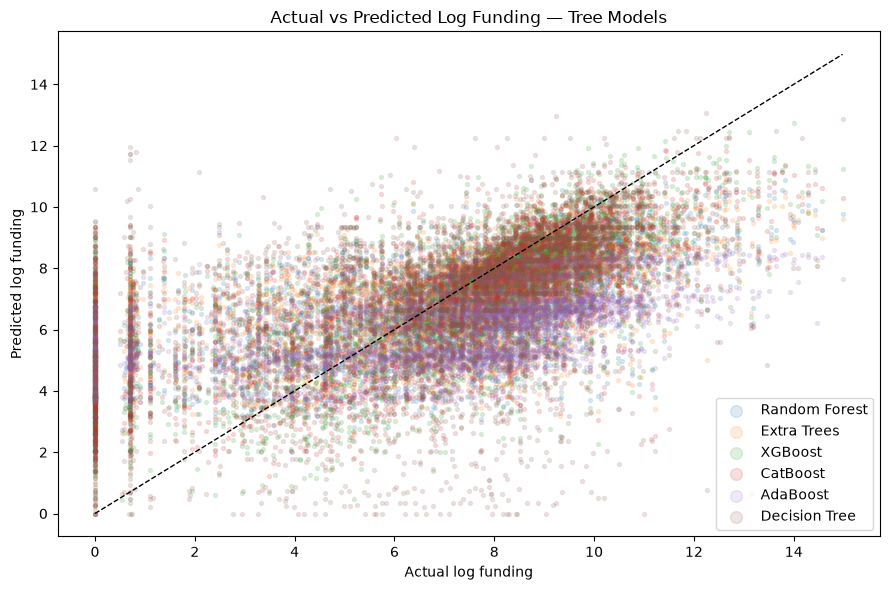

In [69]:
plt.figure(figsize=(9, 6))

for pred_log, label in [
    (rf_pred_log,  "Random Forest"),
    (et_pred_log,  "Extra Trees"),
    (xgb_pred_log, "XGBoost"),
    (cat_pred_log, "CatBoost"),
    (ada_pred_log, "AdaBoost"),
    (dt_pred_log,  "Decision Tree")
]:
    plt.scatter(
        y_test,
        pred_log,
        alpha=0.15,
        s=8,
        label=label
    )

mn = float(y_test.min())
mx = float(y_test.max())
plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
plt.xlabel("Actual log funding")
plt.ylabel("Predicted log funding")
plt.title("Actual vs Predicted Log Funding — Tree Models")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()


## Cell 49 — Actual vs predicted log funding (linear / distance models)


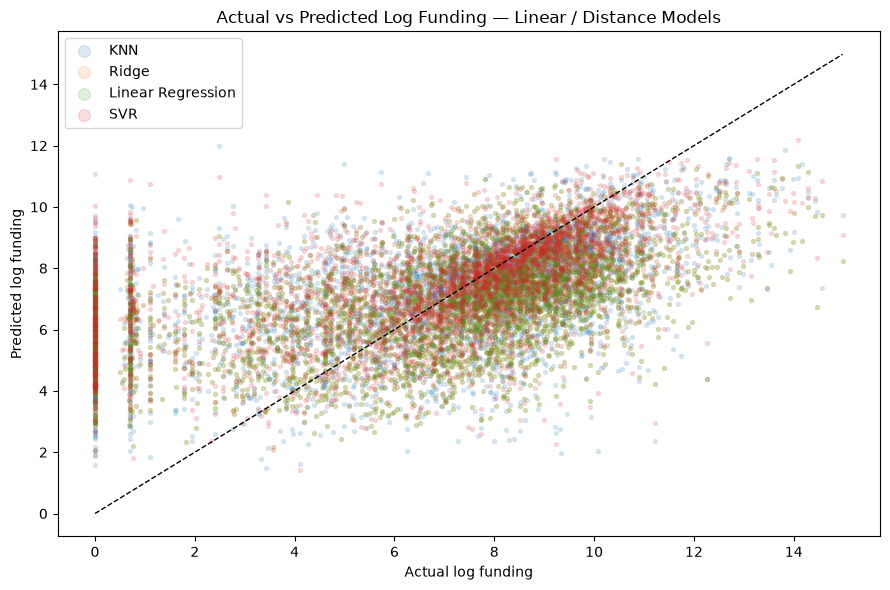

In [70]:
plt.figure(figsize=(9, 6))

for pred_log, label in [
    (knn_pred_log,   "KNN"),
    (ridge_pred_log, "Ridge"),
    (lr_pred_log,    "Linear Regression"),
    (svr_pred_log,   "SVR")
]:
    plt.scatter(
        y_test,
        pred_log,
        alpha=0.15,
        s=8,
        label=label
    )

mn = float(y_test.min())
mx = float(y_test.max())
plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
plt.xlabel("Actual log funding")
plt.ylabel("Predicted log funding")
plt.title("Actual vs Predicted Log Funding — Linear / Distance Models")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()


## Cell 50 — RMSLE comparison (all 10 models)


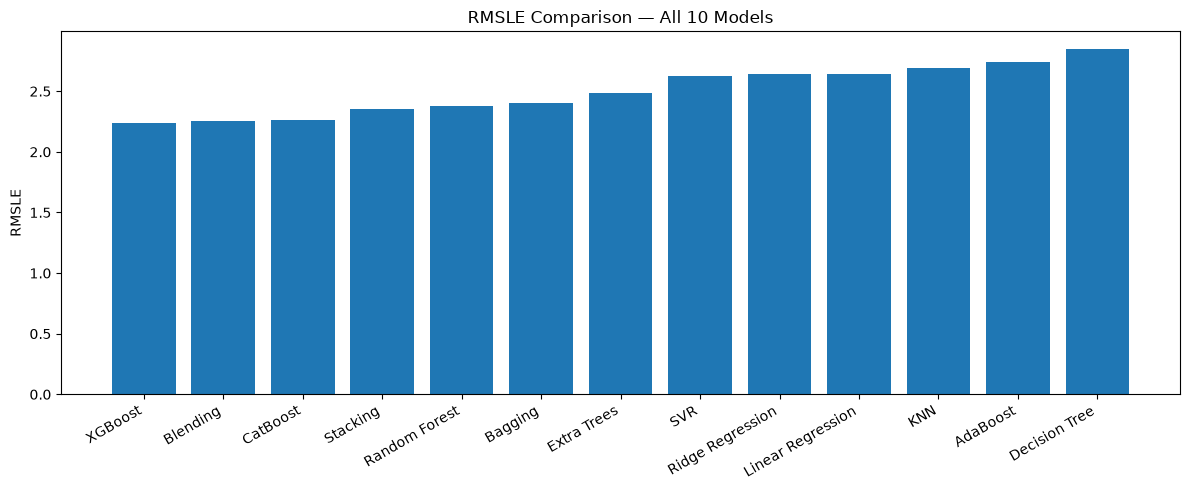

In [71]:
plot_df = (
    comparison_df
    .sort_values("RMSLE")
)

plt.figure(figsize=(12, 5))
plt.bar(
    plot_df["Model"],
    plot_df["RMSLE"]
)
plt.ylabel("RMSLE")
plt.title("RMSLE Comparison — All 10 Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 51 — MSE (log scale) comparison (all 10 models)


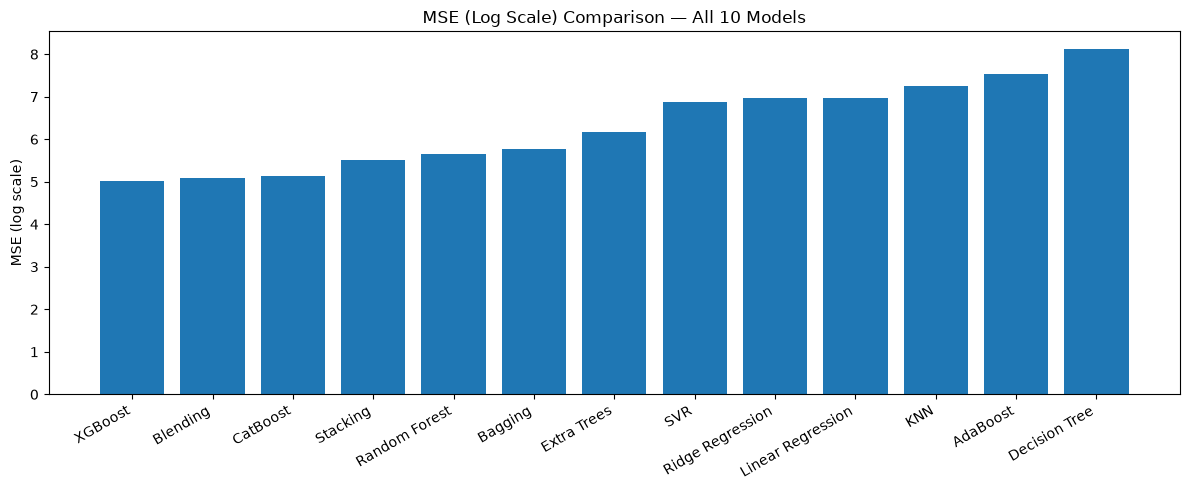

In [72]:
plot_df = (
    comparison_df
    .sort_values("MSE_log")
)

plt.figure(figsize=(12, 5))
plt.bar(
    plot_df["Model"],
    plot_df["MSE_log"]
)
plt.ylabel("MSE (log scale)")
plt.title("MSE (Log Scale) Comparison — All 10 Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 52 — Log-scale R² comparison (all 10 models)


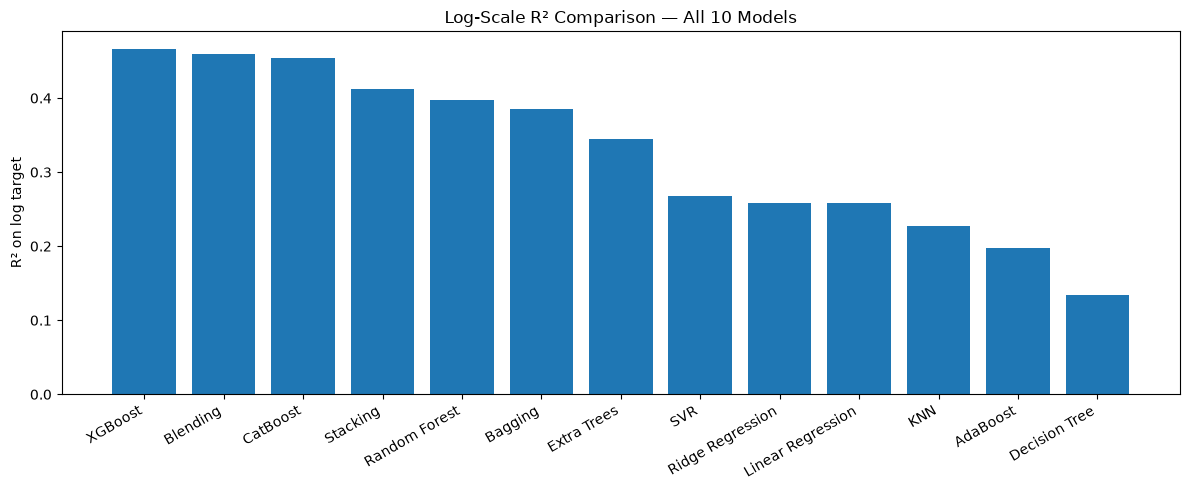

In [73]:
plot_df = (
    comparison_df
    .sort_values(
        "R2_log",
        ascending=False
    )
)

plt.figure(figsize=(12, 5))
plt.bar(
    plot_df["Model"],
    plot_df["R2_log"]
)
plt.ylabel("R² on log target")
plt.title("Log-Scale R² Comparison — All 10 Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Save Results


## Cell 53 — Save model comparison metrics


In [74]:
comparison_df.to_csv(
    "kickstarter_all_models_ensembles_comparison.csv",
    index=False
)

print(
    "Saved:",
    "kickstarter_all_models_ensembles_comparison.csv"
)


Saved: kickstarter_all_models_ensembles_comparison.csv


## Cell 54 — Save predictions


In [75]:
predictions_df.to_csv(
    "kickstarter_all_models_predictions.csv",
    index=False
)

print(
    "Saved:",
    "kickstarter_all_models_predictions.csv"
)


Saved: kickstarter_all_models_predictions.csv


# Final Notes

All 10 models use the same training set, test set, encoded features, and `log_target`.

**Scaling strategy:**

| Model group | Uses scaled features? |
| --- | --- |
| Random Forest, Extra Trees, XGBoost, Decision Tree, AdaBoost, CatBoost | No (`X_train`, `X_test`) |
| KNN, Ridge, Linear Regression, SVR | Yes (`X_train_scaled`, `X_test_scaled`) |

**Metrics (lower = better except R²):**

- **MAE_log** — mean absolute error on log-transformed target
- **MSE_log** — mean squared error on log-transformed target *(baseline metric)*
- **RMSE_log** — root MSE on log target
- **R2_log** — explained variance on log target
- **MAE_USD** — average absolute dollar error
- **MSE_USD** — mean squared dollar error *(baseline metric)*
- **RMSE_USD** — heavily penalises very large dollar errors
- **R2_USD** — explained variance on original dollar scale
- **RMSLE** — primary metric; robust to the highly skewed Kickstarter funding distribution

These are **baseline** settings. Hyperparameter tuning should be done later
using cross-validation on the training set, not the test set.
